# Lab 2 : Classification

## G3 SDI - Machine Learning

In this lab, we will tackle a binary classification problem. We are going to use the MNIST dataset, which contains 28x28 images of handwritten digits. More precisely, our goal will be to distinguish between 3s and 5s using logistic regression and K-nearest neighbors.

### Instructions
* Rename your notebook with your surnames as `lab2_Name1_Name2.ipynb`, and include your names in the notebook.
* Your code, and its output, must be commented !
* Please upload your notebook on Moodle in the dedicated section before the deadline.

**Compte rendu — TP 2.** Auteur : Ugo Roccamatisi.


In [2]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

**Q1.** Load the data from the `.npy` files included in the archive (use `np.load`). How many examples are there ? How many features ? What do the values of the features represent ?

In [4]:
from pathlib import Path
D3=np.load(Path('data3.npy'));D5=np.load(Path('data5.npy'))
print('3 :',D3.shape,'5 :',D5.shape,'intensités :',D3.min(),D3.max())

3 : (1037, 784) 5 : (963, 784) intensités : 0 255


**Réponse.** Il y a 2 000 images (1 037 chiffres 3 et 963 chiffres 5), chacune décrite par 784 pixels en niveaux de gris de 0 à 255.

**Q2.** Display a few examples of 3, and a few examples of 5 (use `plt.imshow`). Comment.

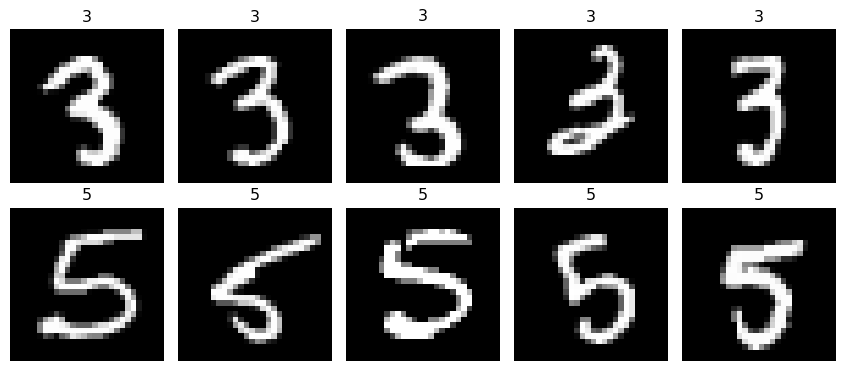

In [7]:
fig,axes=plt.subplots(2,5,figsize=(9,4))
for row,(digits,label) in enumerate(((D3,3),(D5,5))):
    for j,ax in enumerate(axes[row]):ax.imshow(digits[j].reshape(28,28),cmap='gray');ax.set_title(str(label));ax.axis('off')
fig.tight_layout();plt.show()

**Réponse.** L’écriture et l’épaisseur des traits varient ; certaines formes présentent des similitudes visuelles qui peuvent expliquer les erreurs.

**Q3.** Create a variable X which contains all the images (use `np.vstack`), and a variable y which encodes the class.

Normalize the features between 0 and 1.

In [10]:
X=np.vstack((D3,D5)).astype(np.float32)/255.0
y=np.r_[np.zeros(len(D3),dtype=int),np.ones(len(D5),dtype=int)]  # 0=3, 1=5.
print(X.shape,np.unique(y,return_counts=True),X.min(),X.max())

(2000, 784) (array([0, 1]), array([1037,  963])) 0.0 1.0


**Q4.** Split the dataset into a training set and a test set, using 20% of the original dataset for the test set. Do not forget to set the random state.

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=0,stratify=y)
print('Train/test :',X_train.shape,X_test.shape)

Train/test : (1600, 784) (400, 784)


**Q5.** Train a logistic regression model on the training set (see documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)). Recall how the coefficients are obtained.

What does scikit-learn do by default that does not match what we studied during the lecture ?

In [14]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=2000,random_state=0).fit(X_train,y_train)
print('Convergence :',lr.n_iter_[0],'itérations ; intercept :',lr.intercept_[0])

Convergence : 53 itérations ; intercept : 3.427032194998648


**Réponse.** Les paramètres sont obtenus par optimisation numérique de la log-vraisemblance pénalisée. Par défaut, scikit-learn applique une régularisation L2 (`C=1`), souvent absente de la formulation non régularisée vue en cours.

**Q6.** Compute the accuracy on the test set.

In [17]:
from sklearn.metrics import accuracy_score
pred=lr.predict(X_test)
print('Accuracy logistique :',accuracy_score(y_test,pred))

Accuracy logistique : 0.9375


**Q7.** Display the confusion matrix from the test set (add label names), and interpret it.

Vrais 3/5 correctement classés : 193 182 ; confusions 3→5 et 5→3 : 14 11


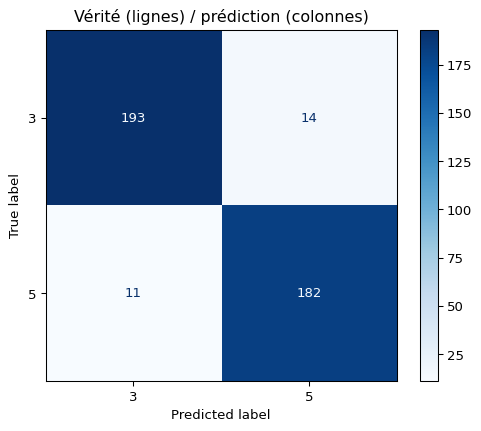

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
cm=confusion_matrix(y_test,pred,labels=[0,1])
ConfusionMatrixDisplay(cm,display_labels=['3','5']).plot(cmap='Blues');plt.title('Vérité (lignes) / prédiction (colonnes)');plt.show()
print('Vrais 3/5 correctement classés :',cm[0,0],cm[1,1],'; confusions 3→5 et 5→3 :',cm[0,1],cm[1,0])

**Réponse.** Les lignes sont les vraies classes (3 puis 5), les colonnes les classes prédites. Les valeurs hors diagonale comptent les deux types de confusion.

**Q8.** Display an example where a 3 was mistaken for 5, and vice versa. Comment.

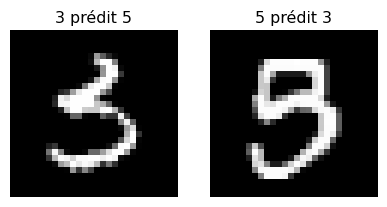

In [22]:
fig,axes=plt.subplots(1,2,figsize=(5,3))
for ax,true,predicted in zip(axes,(0,1),(1,0)):
    idx=np.flatnonzero((y_test==true)&(pred==predicted))
    if len(idx):ax.imshow(X_test[idx[0]].reshape(28,28),cmap='gray');ax.set_title(f'{[3,5][true]} prédit {[3,5][predicted]}')
    else:ax.text(.5,.5,'Aucun cas',ha='center',va='center');ax.set_title(f'{[3,5][true]} → {[3,5][predicted]}')
    ax.axis('off')
plt.show()

**Réponse.** Les images, lorsqu’elles existent dans le test, permettent de voir les formes ambiguës ; l’absence éventuelle d’un type d’erreur est explicitement affichée.

**Q9.** As we have seen during the lecture, the logistic regression model does not directly output a 0 or a 1, but rather the probability of being 0 or 1 (given x), which can be accessed with the `.predict_proba` attribute. This probability is then compared to a threshold to output the prediction, the default threshold being 0.5.

Recall what is the underlying assumption of using a threshold of 0.5.

Display the evolution of the precision and recall (using the 5s as the reference class), as well as the F1-score, when the threshold varies between 0 and 1. Comment.

À 0,5 : précision/rappel/F1 [0.929 0.943 0.936]


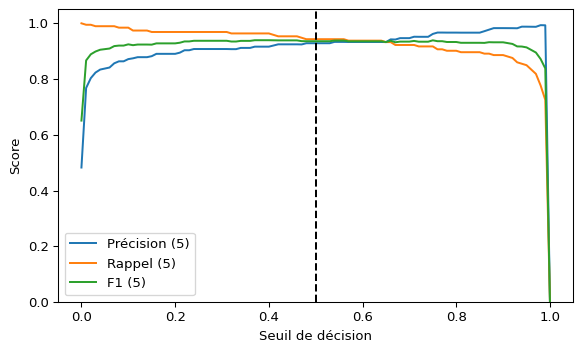

In [25]:
from sklearn.metrics import precision_score,recall_score,f1_score
p5=lr.predict_proba(X_test)[:,1];thresholds=np.linspace(0,1,101)
values=np.array([(precision_score(y_test,p5>=t,zero_division=0),recall_score(y_test,p5>=t,zero_division=0),f1_score(y_test,p5>=t,zero_division=0)) for t in thresholds])
fig,ax=plt.subplots(figsize=(7,4))
for j,name in enumerate(('Précision (5)','Rappel (5)','F1 (5)')):ax.plot(thresholds,values[:,j],label=name)
ax.axvline(.5,color='k',ls='--');ax.set(xlabel='Seuil de décision',ylabel='Score',ylim=(0,1.05));ax.legend();plt.show()
print('À 0,5 : précision/rappel/F1',np.round(values[50],3))

**Réponse.** Un seuil de 0,5 correspond à des coûts d’erreurs identiques pour les deux classes si les probabilités sont calibrées. Augmenter le seuil rend généralement la détection des 5 plus précise mais moins sensible (rappel plus faible). Les scores aux extrêmes utilisent `zero_division=0`.

**Q10.** Lastly, we would like to check the performance of KNN on this dataset. To do so, select the optimal value of $K$ by cross-validation on the training set, and then compute the accuracy score of the optimal KNN on the test set. Comment.

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score
ks=[1,3,5,7,9,11,15]
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=0)
scores=[cross_val_score(KNeighborsClassifier(n_neighbors=k,n_jobs=-1),X_train,y_train,cv=cv,scoring='accuracy').mean() for k in ks]
chosen_k=ks[int(np.argmax(scores))]
knn=KNeighborsClassifier(n_neighbors=chosen_k,n_jobs=-1).fit(X_train,y_train)
print('CV :',list(zip(ks,np.round(scores,4))))
print(f'Meilleur k={chosen_k}; accuracy test KNN={knn.score(X_test,y_test):.4f}; logistique={accuracy_score(y_test,pred):.4f}')

CV : [(1, np.float64(0.9706)), (3, np.float64(0.9794)), (5, np.float64(0.9781)), (7, np.float64(0.9769)), (9, np.float64(0.9794)), (11, np.float64(0.98)), (15, np.float64(0.9781))]
Meilleur k=11; accuracy test KNN=0.9700; logistique=0.9375


**Réponse.** Le choix de k se fait uniquement sur le train. La dernière ligne compare les précisions sur le même test, jamais utilisé pour choisir k.